# GARCH Estimation 

GARCH(1,1) model is defined as follows:
 For log return series $r_t=\mu-\varepsilon_t$ let $\varepsilon_t=\sigma_tz_t$, $z_t$ is i.i.d. with 0 mean and variance 1
$$\sigma_t^2=\omega+\alpha \varepsilon_{t-1}^2+\beta \sigma_{t-1}^2$$ 
$$\omega>0, \alpha >=0 , \beta >=0, \alpha + \beta < 1$$ 

where $\sigma_t^2$ is estimated by bootstrapping procedure

 # Load data

In [18]:
import pandas as pd

df = pd.read_csv('sp500_v1.csv', parse_dates=True, index_col=0)
df.head()


,sp
1926-01-01,2.22213
1926-02-01,-4.49555
1926-03-01,-6.09290
1926-04-01,2.24364
1926-05-01,0.76507


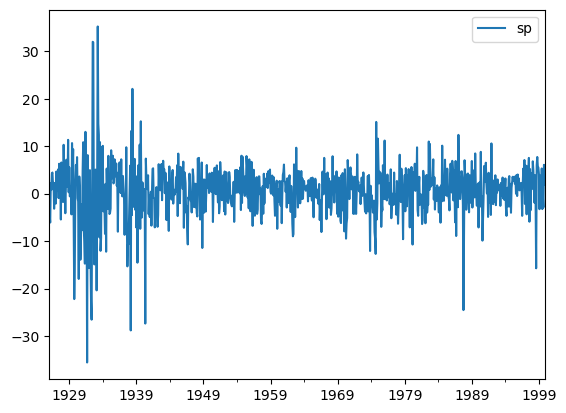

In [19]:
#plot data
import matplotlib.pyplot as plt
df.plot()
plt.show()

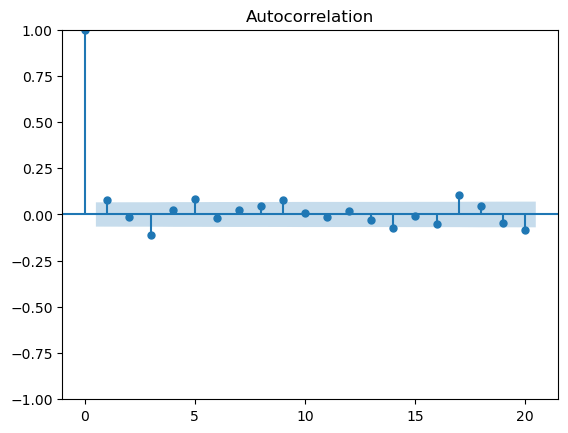

In [20]:
# plot ACF and PACF functions
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df, lags=20)
plt.show()

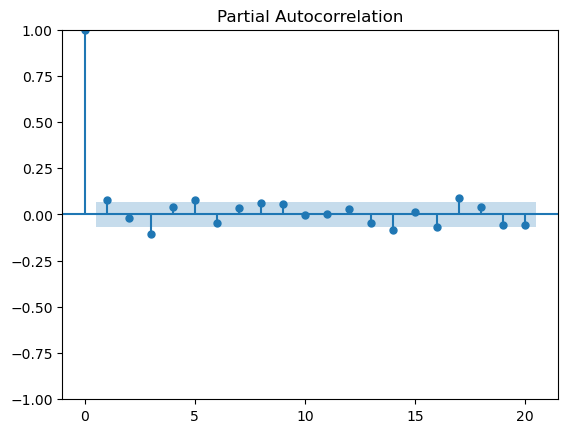

In [21]:
#plot PACF function
plot_pacf(df, lags=20)
plt.show()

In [22]:
#ARMA(3,0) model
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df, order=(3, 0, 0))
results_ARMA = model.fit()
results_ARMA.summary()

C:\Users\nadia\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\nadia\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\nadia\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     sp   No. Observations:                  888
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -2788.415
Date:                Thu, 19 Feb 2026   AIC                           5586.830
Time:                        07:46:02   BIC                           5610.775
Sample:                    01-01-1926   HQIC                          5595.983
                         - 12-01-1999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5374      0.196      2.738      0.006       0.153       0.922
ar.L1          0.0753      0.021      3.619      0.000       0.034       0.116
ar.L2         -0.0133      0.020     -0.649      0.516      -0.053       0.027
ar.L3         -0.1079      0.020     -5.489      0.000      -0.146      -0.069
sigma2        31.2575      0.782     39.989      0.000      29.725      32.790
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):              1922.56
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               0.31   Skew:                            -0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
#squared residuals:
residuals = results_ARMA.resid 
squared_residuals = residuals**2
eps_t = squared_residuals.iloc[-1]
eps_t

21.966006695169387

In [24]:
#GARCH model
from arch import arch_model
am = arch_model(df, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
res = am.fit(disp='off')

In [25]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                     sp   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2641.68
Distribution:                  Normal   AIC:                           5291.35
Method:            Maximum Likelihood   BIC:                           5310.51
                                        No. Observations:                  888
Date:                Thu, Feb 19 2026   Df Residuals:                      887
Time:                        07:46:07   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.6865      0.151      4.556  5.203e-06 [  0.391,  0.982]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.6385      0.308      2.076  3.791e-02 [3.565e-02,  1.241]
alpha[1]       0.1158  2.461e-02      4.706  2.526e-06 [6.758e-02,  0.164]
beta[1]        0.8667  2.502e-02     34.640 6.412e-263   [  0.818,  0.916]
==========================================================================

Covariance estimator: robust
"""

# Predicting with ARMA(3,0,0) model

Substitute coefficient computed by statsmode ARIMA model to ARMA(3,0) equation 

$$x_t=0.5374+0.0753x_{t-1}-0.0133x_{t-2}-0.1079x_{t-3} + \varepsilon_{t-1}$$

one step ahead forecast, given $x_{t-1} = 5.62291, x_{t-2} = 1.88806, x_{t-3} = 6.066233$



$$x_t=0.5374+0.0753*5.62291-0.0133*1.88806-0.1079*6.066233=0.2811474$$

$$x_t=0.5374+0.0753*5.62291-0.0133*1.88806-0.1079*6.066233 + \varepsilon_{t-1}$$

# Predicting volatility with GARCH(1,1)


$$\sigma_t^2=\omega+\alpha \varepsilon_{t-1}^2+\beta \sigma_{t-1}^2=0.6385+0.1158 \varepsilon_{t-1}^2+0.8667 \sigma_{t-1}^2$$ 


hint: unconditional (long-run) variance is $\sigma_0^2=\omega/(1-\alpha - \beta)=36.48$

In [3]:
# one step forecast 


since $\varepsilon_t=\sigma_tz_t$, $z_t$ is i.i.d. with 0 mean and variance 1

$\varepsilon_t^2=\sigma_t^2z_t^2$

Conditional on past information $F_{t-1}$ the expectation of $\varepsilon_t^2$ is
$E[\varepsilon_t^2|F_{t-1}]=\sigma_t^2E[z_t^2|F_{t-1}]=\sigma_t^2$
 

the squared residuls from ARMA model at the last time step  can be used to initialize shock and variance in the GARCH model. 

$\varepsilon_{t-1}^2=\sigma_{t-1}^2=21.97$ the prediction is computed as follows:


$$\sigma_t^2=\omega+\alpha \varepsilon_{t-1}^2+\beta \sigma_{t-1}^2=0.6385+0.1158* 21.97+0.8667 *21.97=22.224$$ 

#two-step forecast

given past value of the variance $\sigma_{t}^2=31.85$ the prediction is computed as follows:

$$\sigma_{t+1}^2=\omega+\alpha \varepsilon_{t}^2+\beta \sigma_{t}^2=0.6385+0.1158* 22.224+0.8667 *22.224=22.473$$ 